# Fitting data with EasyScience

The `easyscience` library is designed to enable model-dependent analysis, using a pure Python interface, and give access to a range of optimization algorithms. 
It is possible to analyse any data for which there is a closed-form mathematical description (i.e., a mathematical model) with parameters to be refined. 

## 🛠️ Import Library
We start by importing the `easyscience` library and other supporting libraries for data-creation, manipulation and plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from easyscience import global_object

We are in the process of refactoring our library, so we have started giving legacy errors upon importing certain classes, here we disable that warning.

In [2]:
global_object.log.getLogger('legacy').setLevel('ERROR') # suppress warnings from legacy code in this notebook

We can now import the entirety of `easyscience` without getting a legacy warning.

In [3]:
import easyscience as es

## 📘 Introduction: Simple quadratic fit

This short demonstration will show how `easyscience` can be used to analyse the toy problem of data following a quadratic relationship. 
We manufacture some quadratic data to work with below. 
````{margin}
```{note}
We set the random seed to ensure reproducibility in this example. 
```
````

In [4]:
np.random.seed(123)

a_true = -0.9594
b_true = 7.294
c_true = 3.102

N = 25
x = np.linspace(0, 10, N)

yerr = 1 + 1 * np.random.rand(N)
y = a_true * x ** 2 + b_true * x + c_true
y += np.abs(y) * 0.1 * np.random.randn(N)

The data created above is shown as a standard error bar plot below.

plt.errorbar(x, y, yerr, marker='.', ls='', color='k')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

The next step is to create an `easyscience` analysis model. 
In this example, this consists of three parameters called `a`, `b`, and `c`.
These parameters are created and initialised with the true values from above, they are all set with `fixed=False` as the parameters should be allowed to vary, to find the optimum solution -- the only one that maximises the likelihood. 

In [5]:
a = es.Parameter(name='a', value=a_true, fixed=False)
b = es.Parameter(name='b', value=b_true, fixed=False)
c = es.Parameter(name='c', value=c_true, fixed=False)

The mathematical model that is to be optimised is
```{math}
:label: quadratic
y = a x ^ 2 + b x + c.
```

To use `easyscience` to optimise this, a Python function that implements this mathematical model is needed. 

We can create a function that implements this mathematical model as shown below. 

In [6]:
def math_model(x: np.ndarray) -> np.ndarray:
    """
    Mathematical model for a quadratic. 
    
    :x: values to calculate the model over. 
    
    :return: model values.
    """
    return a.value * x ** 2 + b.value * x + c.value

The initial guess (from the true value) for the mathematical model, along with the experimental data, can then be plotted. 

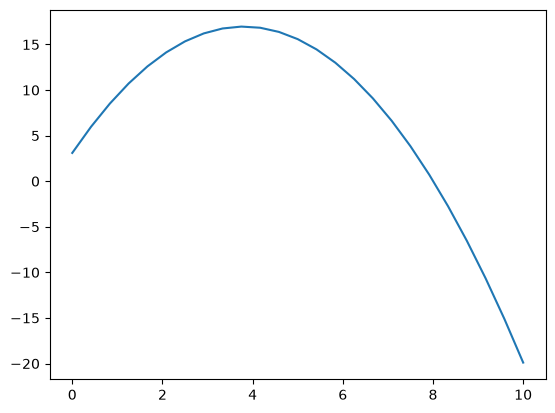

In [7]:
plt.plot(x, math_model(x), '-')

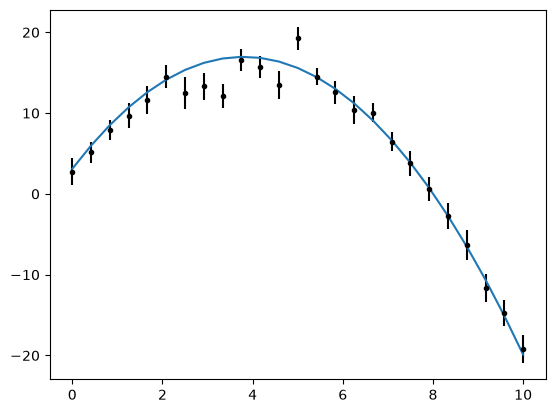

In [8]:
plt.errorbar(x, y, yerr, marker='.', ls='', color='k')
plt.plot(x, math_model(x), '-')
#plt.xlabel('$x$')
#plt.ylabel('$y$')
plt.show()

To optimise the parameters `a`, `b`, and `c`, an `ObjBase` must be created. 
This brings together all parameters to be optimised in a single object, which is then associated with the mathematical model in the `Fitter`. 

In [9]:
container = es.ObjBase(name='quad', a=a, b=b, c=c)
fitter = es.Fitter(container, math_model)

`easyscience` can then be used to determine the parameters of the quadratic model using {term}`maximum likelihood estimation` (MLE).<br>
`easyscience` exposes multiple optimization algorithms from its 3 underlying minimization libraries, the list of available methods can be shown with:

In [10]:
fitter.available_minimizers

['LMFit',
 'LMFit_leastsq',
 'LMFit_powell',
 'LMFit_cobyla',
 'LMFit_differential_evolution',
 'LMFit_scipy_least_squares',
 'Bumps',
 'Bumps_simplex',
 'Bumps_newton',
 'Bumps_lm',
 'DFO',
 'DFO_leastsq']

The minimization method on the `Fitter` can be changed, as well as the minimization convergence criteria tolerance and the algorithms maximum number of iterations.

In [11]:
fitter.switch_minimizer(es.AvailableMinimizers.LMFit_leastsq)
fitter.tolerance = 1e-3
fitter.max_evaluations = 2000

We then perform the fit where `y` describes the position of the normal distributions mean for the data while the `weights` are the reciprocals of their standard deviations, to ensure that measurements with higher uncertainties are prioritised less.

In [12]:
results = fitter.fit(x=x, y=y, weights=1/yerr)

With the MLE found, the parameters can be printed to screen to see the optimized values and estimated statistical uncertainties. 

In [13]:
a, b, c

(<Parameter 'a': -0.9455 ± 0.0379, bounds=[-inf:inf]>,
 <Parameter 'b': 7.3277 ± 0.3800, bounds=[-inf:inf]>,
 <Parameter 'c': 2.0301 ± 0.8187, bounds=[-inf:inf]>)

The fitting results can also be printed to screen to inspect the number of iterations used and the fit quality.<br>
The reduced $\chi^2$ (written chi2) is a numerical estimate of how well the optimization managed to maximize the likelihoods.

In [14]:
results

FitResults(success=True
  n_pars=3, n_points=25
  chi2=22.75, reduced_chi2=1.034
  n_evaluations=9
  iterations=9
  minimizer=LMFit
  message='Fit succeeded.'
  parameters={pParameter_0=-0.9455, pParameter_1=7.328, pParameter_2=2.03}
)

Finally, the optimised model can be plotted with the experimental data, using the same visualisation as [previously](./prob_data.ipynb). 

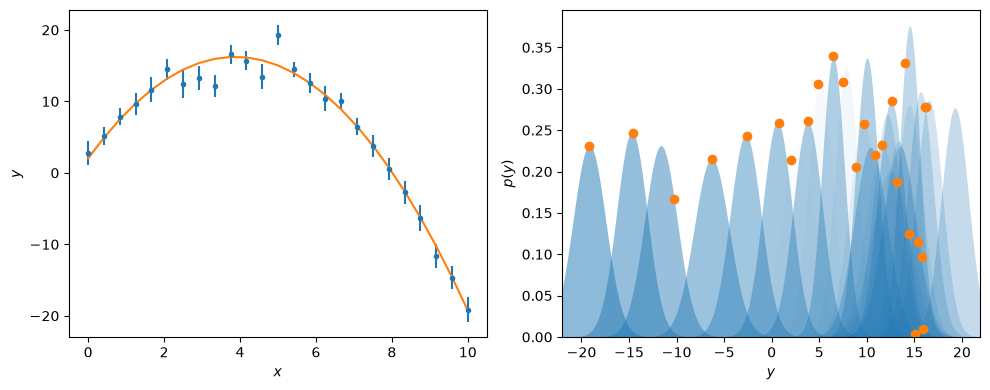

In [15]:
from scipy.stats import norm

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].errorbar(x, y, yerr, marker='.', ls='', color='C0')
ax[0].plot(x, math_model(x), '-', color='C1')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')

y_range = np.arange(-22, 22, 0.1)
for i, yy in enumerate(y):
    ax[1].fill_between(y_range, norm(yy, yerr[i]).pdf(y_range), color='C0', alpha=0.02 * (i + 1), lw=0)
    ax[1].plot(math_model(x[i]), norm(yy, yerr[i]).pdf(math_model(x[i])), 'C1o')
ax[1].set_xlim(y_range.min(), y_range.max())
ax[1].set_ylim(0, None)
ax[1].set_xlabel('$y$')
ax[1].set_ylabel('$p(y)$')
plt.tight_layout()
plt.show()

This approach to use `easyscience` for the optimization of mathematical models can be applied to many different use cases, including in neutron scattering. 

## 💪 Exercise: Gaussian fit

Use what you just learned to make a Gaussian model to fit a Gaussian dataset. The Gaussian model takes the following form:

$$ f(x) = A \cdot e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$ (gauss)

Where $A$ is the amplitude of the Gaussian, $\mu$ is the mean/center point of the Gaussian and $\sigma$ is its width/standard deviation

First we manufacture some data to be fitted.

In [56]:
np.random.seed(1337)

N = 40

x = np.linspace(-10, 10, N)

from scipy.stats import Normal
mu = (np.random.rand(1)-0.5)*4
sigma = np.random.rand(1)*2+1
amplitude = np.random.rand(1)*20
gauss = Normal(mu=mu, sigma=sigma)
y = gauss.pdf(x)*amplitude
yerr = 0.1 * np.random.rand(N) + 0.1*y*np.random.rand(N) + 0.05 + 0.05*y
for i in range(N):
    y_extra = Normal(mu=y[i], sigma=yerr[i]).sample(1)[0]*0.2
    y[i]+= y_extra

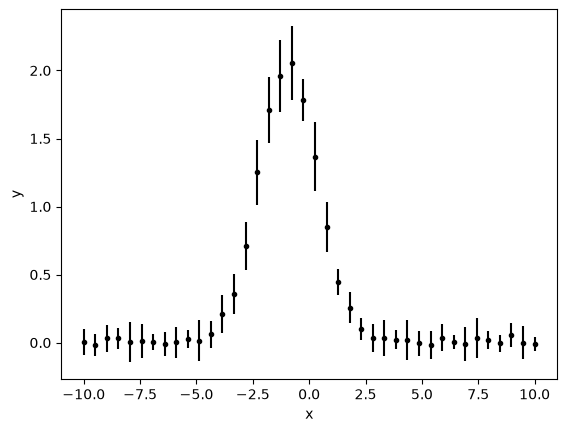

In [57]:
plt.errorbar(x, y, yerr, marker='.', ls='', color='k')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### 🧩 Exercise 1: Create the model parameters
Create the 3 `easyscience` `Parameters` corresponding to the 3 parameters of the Gaussian model: the Amplitude $A$, the Mean $\mu$ and the width $\sigma$

**Hint:**

```{toggle}
You can look at how the `Parameters` are created earlier in this notebook. You can guess at their initial values from the plot above.
```

**Solution:**

In [58]:
amplitude = es.Parameter(name='amplitude', value=2.0, fixed=False)
mean = es.Parameter(name='mean', value=-3.0, fixed=False)
width = es.Parameter(name='width', value=3.0, fixed=False)

### 🧩 Exercise 2: Create the mathematical model
Create the Python function which uses the `easyscience` parameters to return the Gaussian model given by {eq}`gauss`

**Hint:**

```{toggle}
Write the python function like in the example above. Numpy has an exponential function which you can call by `np.exp(x)`.
```

**Hint:**

```{toggle}
Don't forget to set your parenthesis right, that exponentiation in Python is done with 2 stars: x**2 is $x^2$ and call parameter.value to access parameter values in the function
```

**Solution:**

In [59]:
def gaussian_model(x):
    return amplitude.value * np.exp(-(x-mean.value)**2/(2*(width.value**2)))

### 🧩 Exercise 3: Setup the fit
Create the `ObjBase` to hold the Parameters and create the `Fitter` object.

**Hint:**

```{toggle}
You can look at the start of the notebook for the correct syntax.<br>
Don't forget to give the `ObjBase` and fitter a name and to supply your parameters as keyword arguments to the `ObjBase`
```

**Solution:**

In [60]:
container = es.ObjBase(name='gauss', amplitude=amplitude, mean=mean, width=width)
fitter = es.Fitter(container, gaussian_model)

### 🚀 Exercise 4: Perform the fit
Pass the data and the error to the fitter to perform the fit and inspect the results.

**HINT:**

```{toggle}
Don't forget to pass the uncertaintie to the fitter as 1/yerr, to weigh more uncertain points less in the fit.
```

**Solution:**

In [61]:
results = fitter.fit(x=x, y=y, weights=1/yerr)
mean, amplitude, width, results

(<Parameter 'mean': -0.9580 ± 0.0166, bounds=[-inf:inf]>,
 <Parameter 'amplitude': 2.0640 ± 0.0275, bounds=[-inf:inf]>,
 <Parameter 'width': 1.3011 ± 0.0137, bounds=[-inf:inf]>,
 FitResults(success=True
   n_pars=3, n_points=40
   chi2=1.821, reduced_chi2=0.04921
   n_evaluations=33
   iterations=33
   minimizer=LMFit
   message='Fit succeeded.'
   parameters={pParameter_6=2.064, pParameter_7=-0.958, pParameter_8=1.301}
 ))

How good was the fit? Did you get a small reduced $\chi^2$?<br>
How many minimization steps did the algorithm run for? Could you have gotten a better fit by changing the maximum iterations and/or tolerance?<br>
How big are the estimated uncertainties on the fitted parameters?<br>

Feel free to also try out the different minimization algorithms available in `easyscience`. Changing between them is as easy as:

In [62]:
fitter.switch_minimizer(es.AvailableMinimizers.Bumps)

And then simply run your fit again. It might be prudent to repeat all the steps of setting up the fit first, to ensure you start from the same starting point, if trying out the different algorithms.

And don't forget to compare your model to your dataset visually as well. This is the result you would show in a publication to convince readers that your fit is good and your model is sound.

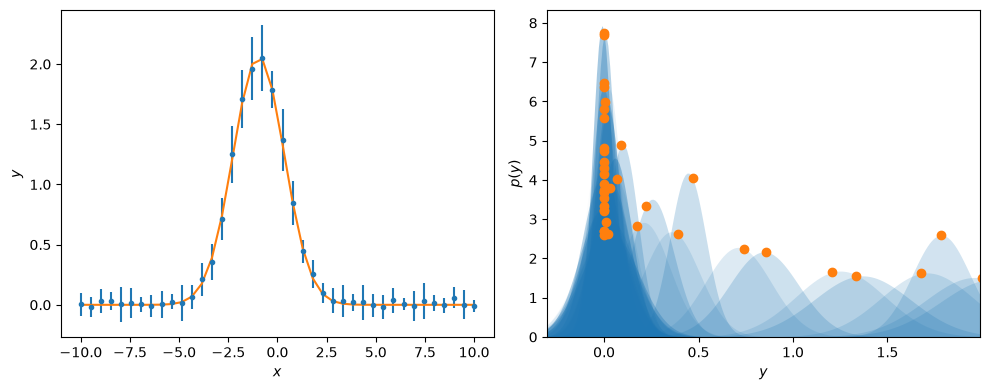

In [63]:
from scipy.stats import norm

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].errorbar(x, y, yerr, marker='.', ls='', color='C0')
ax[0].plot(x, gaussian_model(x), '-', color='C1')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')

y_range = np.arange(-0.3, 2, 0.01)
for i, yy in enumerate(y):
    ax[1].fill_between(y_range, norm(yy, yerr[i]).pdf(y_range), color='C0', alpha=0.01 * (i + 1), lw=0)
    ax[1].plot(gaussian_model(x[i]), norm(yy, yerr[i]).pdf(gaussian_model(x[i])), 'C1o')
ax[1].set_xlim(y_range.min(), y_range.max())
ax[1].set_ylim(0, None)
ax[1].set_xlabel('$y$')
ax[1].set_ylabel('$p(y)$')
plt.tight_layout()
plt.show()

In the next notebook we will learn how to make more comples models in `easyscience`.